In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


{'tesla_deliveries_dataset_2015_2025.csv': b'Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations\n2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207\n2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640\n2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071\n2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333\n2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722\n2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798\n2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961\n2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216\n2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.0,Interpolated (Month),13264\n2021,3,Middle East,Model Y,7790,8208,50

In [ ]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Data Exploration

In [ ]:
print(df.shape)
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
df.describe()

(2640, 12)
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Basic stats:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Preprocessing

In [ ]:
df = df.drop(columns=[col for col in df.columns if 'Source' in col])

df.fillna(df.median(numeric_only=True), inplace=True)

df['Region_Code'] = df['Region'].astype('category').cat.codes
df['Model_Code']  = df['Model'].astype('category').cat.codes

df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

print(df.head())
print(df.dtypes)

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons  Charging_Stations  Region_Code  Model_Code       Date  
0         1863.42              12207            1           2 2023-05-01  
1          249.46               7640        

# EDA

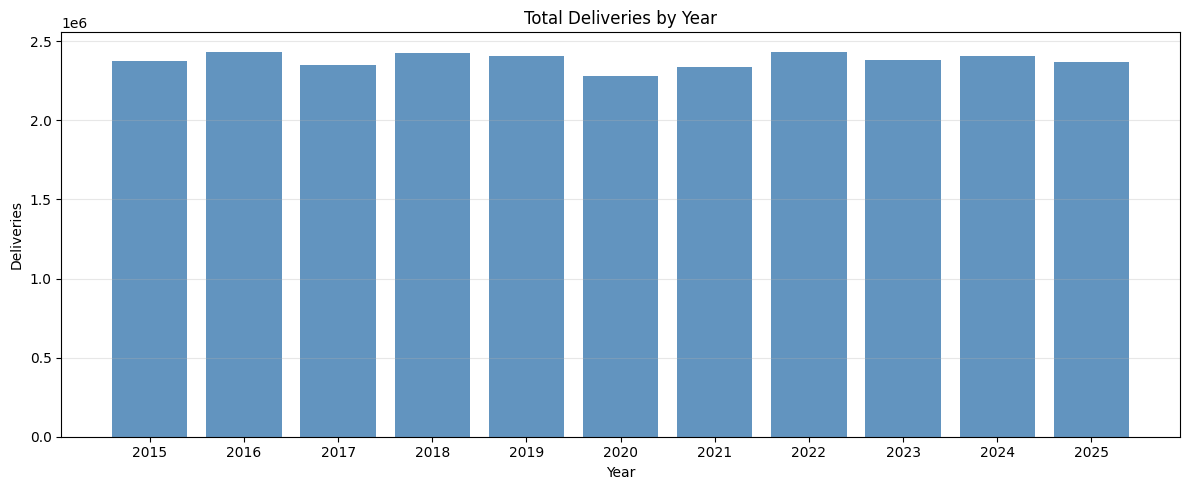

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Deliveries by year
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.bar(yearly['Year'], yearly['Estimated_Deliveries'], color='steelblue', alpha=0.85)
plt.title('Total Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.xticks(yearly['Year'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

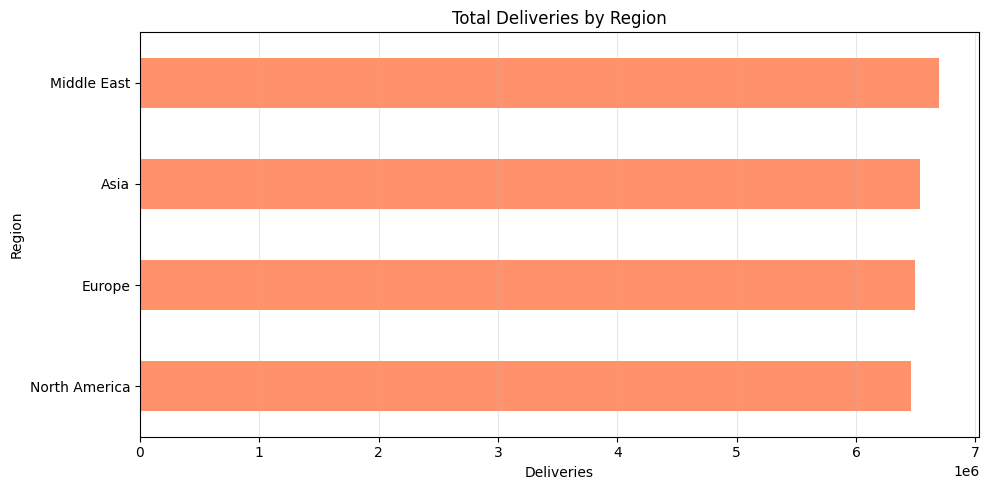

In [ ]:
# Deliveries by Region
plt.figure(figsize=(10, 5))
region_data = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=True)
region_data.plot(kind='barh', color='coral', alpha=0.85)
plt.title('Total Deliveries by Region')
plt.xlabel('Deliveries')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

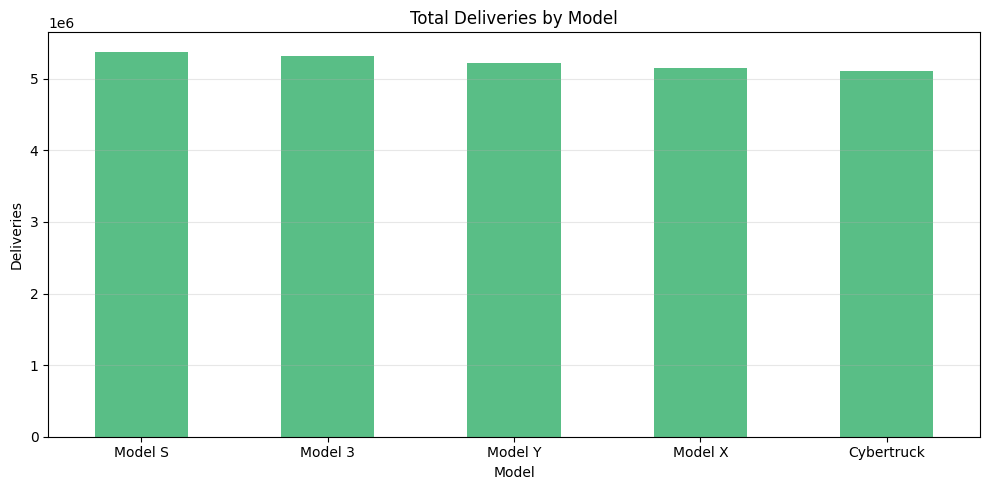

In [ ]:
# Deliveries by Model
model_data = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
model_data.plot(kind='bar', color='mediumseagreen', alpha=0.85)
plt.title('Total Deliveries by Model')
plt.ylabel('Deliveries')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

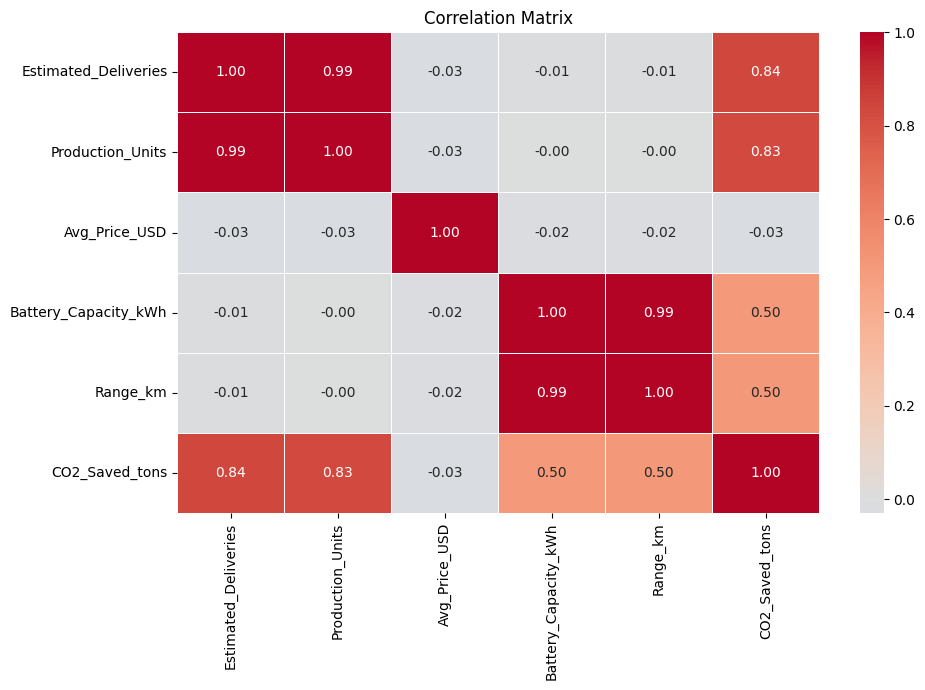

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Feature Engineering

In [ ]:
# Lag features
df = df.sort_values('Date').reset_index(drop=True)

df['Deliveries_lag1'] = df['Estimated_Deliveries'].shift(1)
df['Deliveries_lag3'] = df['Estimated_Deliveries'].shift(3)
df['Production_lag1'] = df['Production_Units'].shift(1)

# Rolling average of 3 month
df['Deliveries_roll3'] = df['Estimated_Deliveries'].rolling(3).mean()

# Price per km range — efficiency metric
df['Price_per_km'] = df['Avg_Price_USD'] / df['Range_km']

# CO2 efficiency
df['CO2_per_unit'] = df['CO2_Saved_tons'] / df['Estimated_Deliveries']

# Drop rows that got NaN from shifting
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape after feature engineering: {df.shape}")
print(df.head())

Shape after feature engineering: (2637, 20)
   Year  Month         Region       Model  Estimated_Deliveries  \
0  2015      1  North America  Cybertruck                  6367   
1  2015      1           Asia     Model 3                  8795   
2  2015      1         Europe  Cybertruck                  2161   
3  2015      1  North America     Model S                 11986   
4  2015      1         Europe     Model X                  8833   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0              6802      104962.32                    82       459   
1              9165       87988.73                    82       456   
2              2465      112637.91                   120       695   
3             13302       91906.09                    82       457   
4              8878      113652.43                    82       461   

   CO2_Saved_tons  Charging_Stations  Region_Code  Model_Code       Date  \
0          438.37               9170            3       

# Regression Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np

FEATURES = [
    'Year', 'Month', 'Region_Code', 'Model_Code',
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Price_per_km', 'CO2_per_unit',
    'Deliveries_lag1', 'Deliveries_lag3',
    'Production_lag1', 'Deliveries_roll3'
]
TARGET = 'Estimated_Deliveries'

X = df[FEATURES]
y = df[TARGET]

# Chronological split
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

def evaluate(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    mae  = mean_absolute_error(yte, pred)
    r2   = r2_score(yte, pred)
    print(f"{name:<25} RMSE={rmse:>8,.0f}  MAE={mae:>8,.0f}  R²={r2:.4f}")
    return {"name": name, "model": model, "pred": pred, "rmse": rmse, "mae": mae, "r2": r2}

print(f"{'Model':<25} {'RMSE':>14} {'MAE':>14} {'R²':>8}")
print("-" * 65)
results = []
results.append(evaluate("Linear Regression",   LinearRegression(),   X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate("Ridge",               Ridge(alpha=10),      X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate("Lasso",               Lasso(alpha=10),      X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate("Random Forest",       RandomForestRegressor(n_estimators=200, random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate("XGBoost",             XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42, verbosity=0), X_train, X_test, y_train, y_test))
results.append(evaluate("Gradient Boosting",   GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42), X_train, X_test, y_train, y_test))

Model                               RMSE            MAE       R²
-----------------------------------------------------------------
Linear Regression         RMSE=     392  MAE=     323  R²=0.9884
Ridge                     RMSE=     392  MAE=     321  R²=0.9884
Lasso                     RMSE=     394  MAE=     324  R²=0.9883
Random Forest             RMSE=     414  MAE=     331  R²=0.9871
XGBoost                   RMSE=     386  MAE=     313  R²=0.9888
Gradient Boosting         RMSE=     406  MAE=     334  R²=0.9876


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)
gs   = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)

best_model = gs.best_estimator_
pred_tuned = best_model.predict(X_test)
print(f"Tuned RMSE: {np.sqrt(mean_squared_error(y_test, pred_tuned)):,.0f}")
print(f"Tuned R²:   {r2_score(y_test, pred_tuned):.4f}")

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Tuned RMSE: 320
Tuned R²:   0.9923


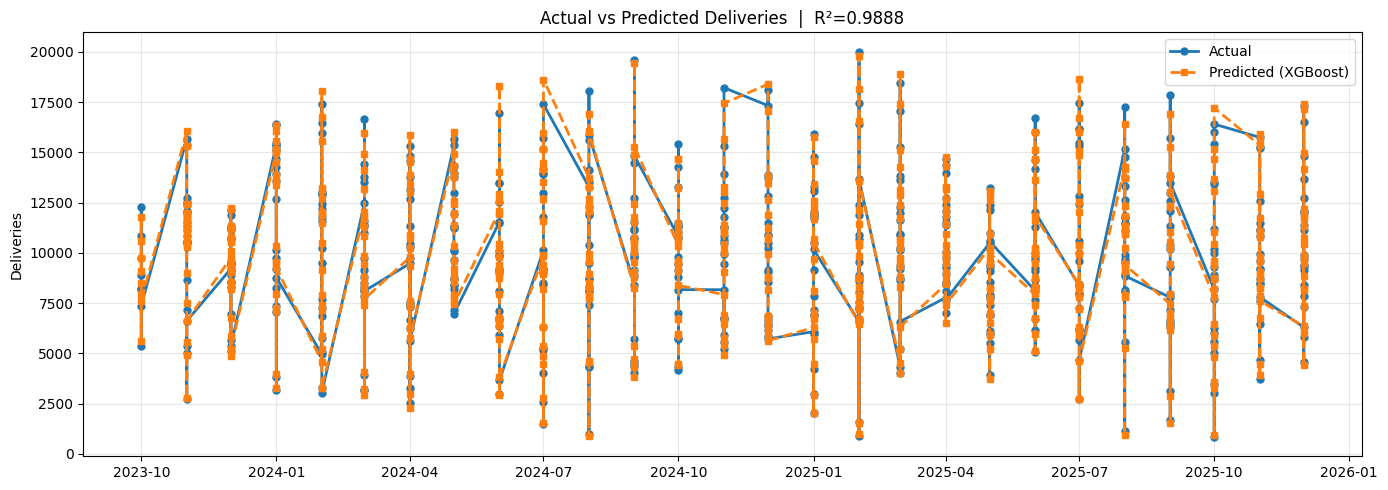

In [ ]:
# Best model prediction vs actual prediction
best = max(results, key=lambda r: r['r2'])
test_dates = df['Date'].iloc[split:]

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test.values, label='Actual', marker='o', markersize=5, linewidth=2)
plt.plot(test_dates, best['pred'], label=f'Predicted ({best["name"]})',
         marker='s', markersize=5, linewidth=2, linestyle='--')
plt.title(f'Actual vs Predicted Deliveries  |  R²={best["r2"]:.4f}')
plt.ylabel('Deliveries')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

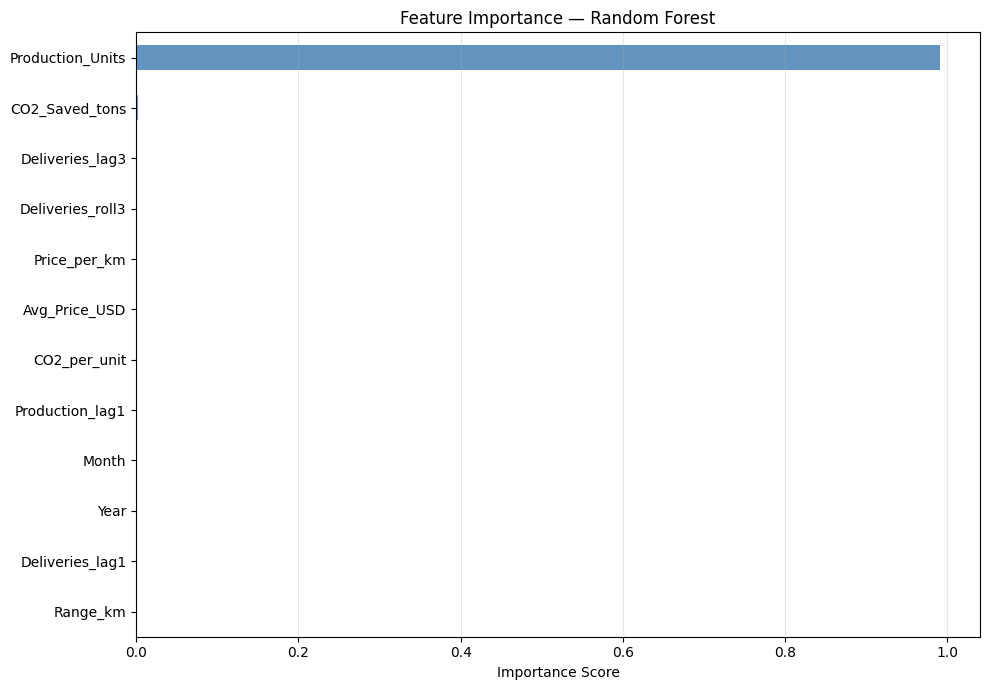

In [ ]:
# Feature from Random Forest
rf = next(r['model'] for r in results if r['name'] == 'Random Forest')
importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(10, 7))
importance.tail(12).plot(kind='barh', color='steelblue', alpha=0.85)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Time Series Forecasting

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Monthly deliveries across all models
ts = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()
ts.index = ts.index.to_period('M')

# Stationarity check
adf = adfuller(ts)
print(f"ADF p-value: {adf[1]:.4f} →", "Stationary ✓" if adf[1] < 0.05 else "Not stationary, will difference")

ADF p-value: 0.0000 → Stationary ✓


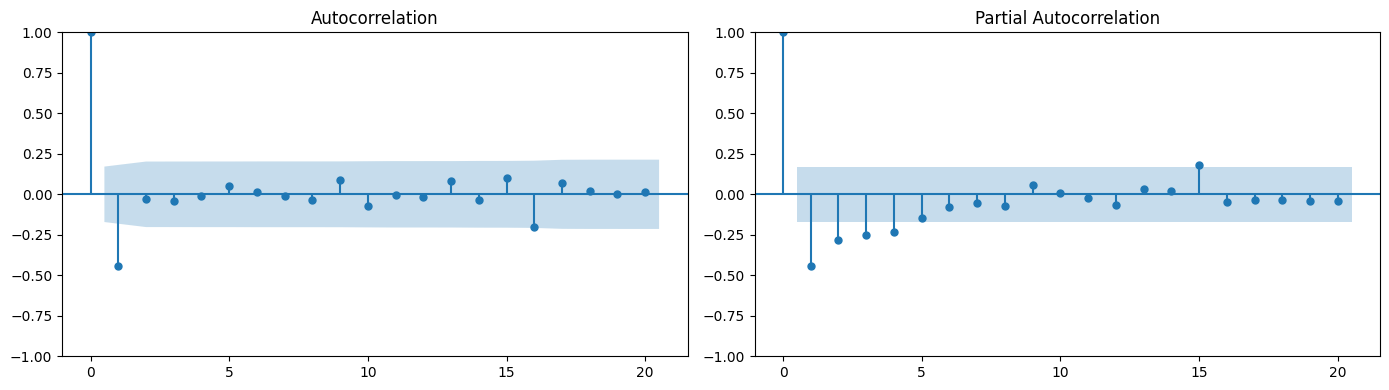

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts.diff().dropna(),  lags=20, ax=axes[0])
plot_pacf(ts.diff().dropna(), lags=20, ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
train_ts = ts[:-6]
test_ts  = ts[-6:]

model  = ARIMA(train_ts, order=(2, 1, 2))
fitted = model.fit()

fc     = fitted.get_forecast(steps=6 + 6)   # 6 test + 6 future
fc_mean = fc.predicted_mean
fc_ci   = fc.conf_int()

pred_test  = fc_mean[:6]
future_fc  = fc_mean[6:]
future_ci  = fc_ci.iloc[6:]

print(f"ARIMA Test RMSE: {np.sqrt(mean_squared_error(test_ts, pred_test)):,.0f}")
print("\nFuture 6-Month Forecast:")
print(future_fc.to_frame("Forecasted_Deliveries").astype(int))

ARIMA Test RMSE: 11,830

Future 6-Month Forecast:
         Forecasted_Deliveries
2026-01                 196036
2026-02                 196036
2026-03                 196036
2026-04                 196036
2026-05                 196036
2026-06                 196036


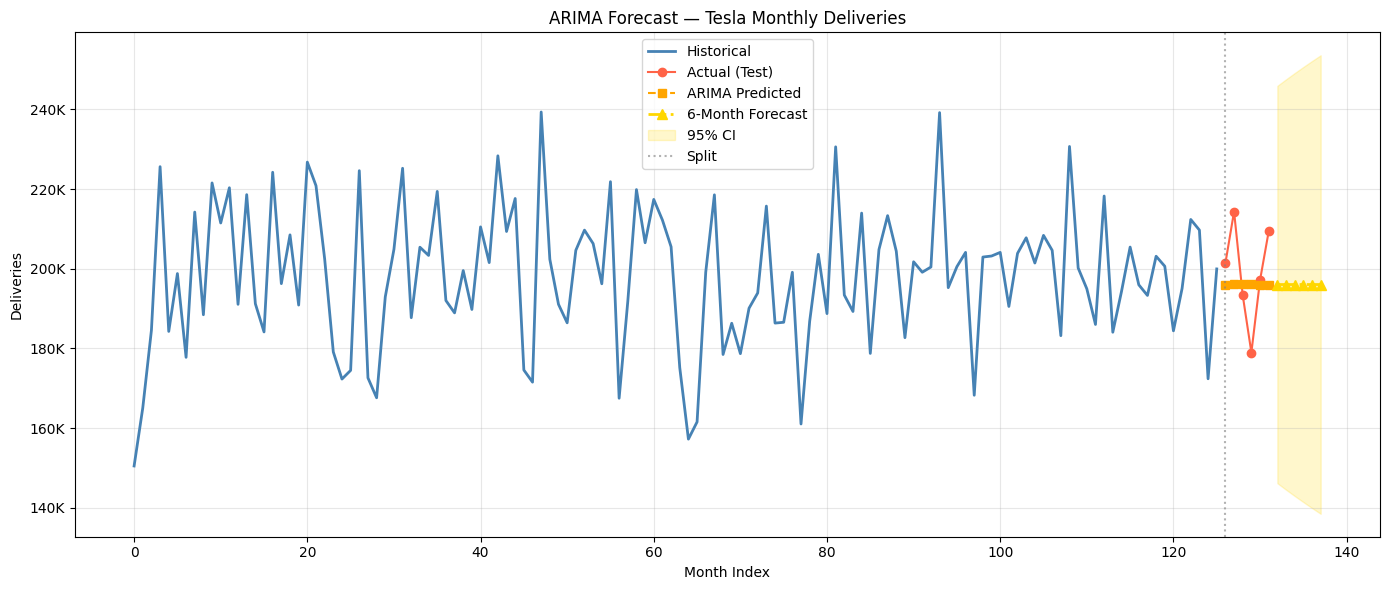

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(len(train_ts)), train_ts.values,
        label='Historical', linewidth=2, color='steelblue')
ax.plot(range(len(train_ts), len(ts)), test_ts.values,
        label='Actual (Test)', marker='o', markersize=6, color='tomato')
ax.plot(range(len(train_ts), len(ts)), pred_test.values,
        label='ARIMA Predicted', linestyle='--', marker='s', markersize=6, color='orange')

fx = range(len(ts), len(ts) + 6)
ax.plot(fx, future_fc.values, label='6-Month Forecast',
        linestyle='-.', marker='^', markersize=7, color='gold', linewidth=2)
ax.fill_between(fx, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                alpha=0.2, color='gold', label='95% CI')

ax.axvline(len(train_ts), color='gray', linestyle=':', alpha=0.6, label='Split')
ax.set_title('ARIMA Forecast — Tesla Monthly Deliveries')
ax.set_xlabel('Month Index')
ax.set_ylabel('Deliveries')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()